In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [56]:
df_skills = df[df['job_title_short']=='Data Analyst'].copy()
df_skills = df_skills.explode('job_skills')
# skills_count = df_skills.groupby(['job_skills']).size()
# df_skills_count = skills_count.reset_index(name='skill_count')
# df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)

# df_skills_count = df_skills_count.reset_index().head(10)
# #df_skills_count.drop(columns=['index'])
# df_skills_count.drop('index', axis=1, inplace=True)
# df_skills_count['median_salary'] = df.groupby['salary_year_avg'].median()


skills_stats = (
    df_skills
    .groupby('job_skills')
    .agg(
        skill_count=('job_skills', 'size'),
        median_salary=('salary_year_avg', 'median')
    )
    .sort_values(by='skill_count', ascending=False)
    .head(10)
)

In [63]:
print(skills_stats.index)

Index(['sql', 'excel', 'python', 'tableau', 'power bi', 'r', 'sas',
       'powerpoint', 'word', 'sap'],
      dtype='str', name='job_skills')


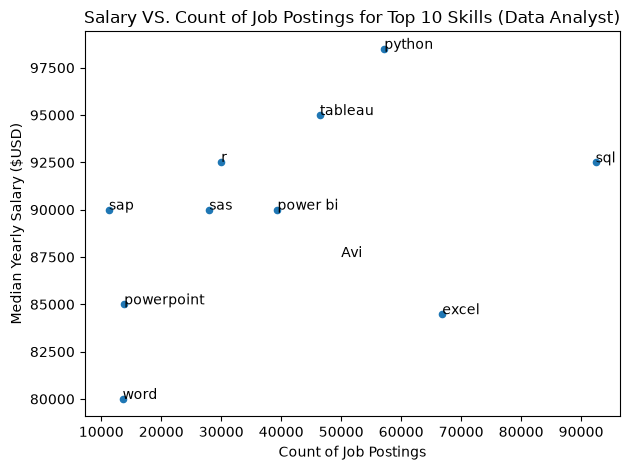

In [69]:
skills_stats.plot(kind='scatter',x='skill_count',y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary VS. Count of Job Postings for Top 10 Skills (Data Analyst)')
plt.tight_layout()

#plt.text(x,y,string) example
plt.text(50000,87500,'Avi')
for i, txt in enumerate(skills_stats.index):
    #trying to break it down into stages, we first want to print out the X,y values per i
    plt.text(skills_stats['skill_count'].iloc[i],
             skills_stats['median_salary'].iloc[i],
             txt)
#    print(i,txt)
plt.show()